#### This notebook reproduces Figure A4 in "Age-related vulnerability greatly amplifies the risk of uncompensable heat" by Kong et al.

In this Jupyter notebook, we aim to establish the heat compensability limits for young, middle-aged and old people covering the whole adult age-spectrum (>18 years). It's based on the following two papers:

- Tony Wolf, S., Cottle, R. M., Fisher, K. G., Vecellio, D. J. & Larry Kenney, W. Heat stress vulnerability and critical environmental limits for older adults. Commun Earth Environ 4, 486 (2023).

- Cottle, R. M., Fisher, K. G., Leach, O. K., Wolf, S. T. & Kenney, W. L. Critical environmental core temperature limits and heart rate thresholds across the adult age span (PSU HEAT Project). Journal of Applied Physiology 137, 145–153 (2024).

Wolf et al. (2023) provides limits for both young (18-34) and old (65 or older) adults. Cottle et al. (2024) conducted the same experimental protocol on 28 individuals aged 40–60, along with 4 adults aged 35–39 and 9 aged 61–64. These 41 participants were combined into a middle-aged cohort spanning ages 35–64. 

In [3]:
"""
import python packages
please install required packages before running this notebook
"""
import xarray as xr
import numpy as np
import dask
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from wetbulb import Twb

In [4]:
# directory to data; you might want to change it to your own directory
path='../data/'

young= pd.read_excel(path+'limits_young.xlsx',sheet_name=None)
old = pd.read_excel(path+'limits_old.xlsx',sheet_name=None)
middle = pd.read_excel(path+'limits_middle_aged.xlsx',sheet_name=None)


In [5]:
# fit segmented linear regression to experiment data
def fit_segmented(x, y, x0_candidates):
    x = np.asarray(x)
    y = np.asarray(y)
    
    best_rss = np.inf
    best_params = None
    
    for x0 in x0_candidates:
        mask1 = x < x0
        mask2 = x >= x0
        
        if np.sum(mask1) < 2 or np.sum(mask2) < 2:
            continue  # skip if not enough data on either side
        
        y_const = np.mean(y[mask1])
        
        x2 = x[mask2]
        y2 = y[mask2] - y_const
        
        model = LinearRegression().fit((x2 - x0).reshape(-1, 1), y2)
        slope = model.coef_[0]
        
        # Predict full fit
        y_fit = np.where(x < x0, y_const, y_const + slope * (x - x0))
        rss = np.sum((y - y_fit) ** 2)
        
        if rss < best_rss:
            best_rss = rss
            best_params = (x0, y_const, slope)
    
    return best_params

# parent function to call fit_segmented()
def getfit(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    
    x0_grid = np.linspace(min(x) + 0.5, max(x) - 0.5, 1000)
    x0_opt, y_const_opt, slope_opt = fit_segmented(x, y, x0_grid)
    x_fit=np.linspace(min(x),max(x),1000)
    y_fit = np.where(x_fit < x0_opt, y_const_opt, y_const_opt + slope_opt * (x_fit - x0_opt))
    return (x0_opt,y_const_opt,slope_opt,x_fit,y_fit)

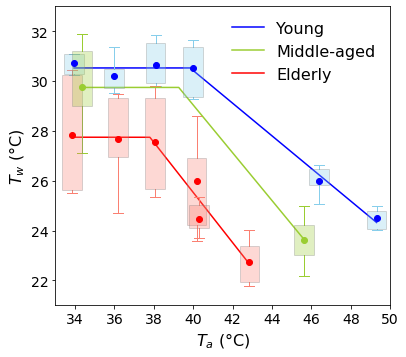

In [6]:
fig = plt.figure(figsize=(6,5.5))
ax=fig.add_subplot(111)
# young adults
x_young=np.asarray(young['mean']['Tdb'])
y_young=np.asarray(young['mean']['Tw'])
# fit segmented linear regression
x0_young,y_const_young,slope_young,x_fit_young,y_fit_young=getfit(x_young,y_young)
ax.plot(x_fit_young, y_fit_young, color='blue',label='Young')
# using boxplot to demonstrate inter-individual spread
ax.boxplot([young[np.array(list(young.keys()))[1]].Tw,
                    young[np.array(list(young.keys()))[2]].Tw,
                    young[np.array(list(young.keys()))[3]].Tw,
                    young[np.array(list(young.keys()))[4]].Tw,
                    young[np.array(list(young.keys()))[5]].Tw,
                    young[np.array(list(young.keys()))[6]].Tw],
          patch_artist=True,
          positions=x_young,
           whis=(10,90),
           showfliers=False,
           medianprops=dict(color='none'),
           whiskerprops=dict(color='skyblue'),  # whisker lines
          capprops=dict(color='skyblue'),      # connecting caps
           showmeans=True,
           widths=1,
           boxprops=dict(facecolor='skyblue', color='grey',alpha=0.3),
          meanprops=dict(marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=6))


# elderly adults
x_old=np.asarray(old['mean']['Tdb'])
y_old=np.asarray(old['mean']['Tw'])
# fit segmented linear regression
x0_old,y_const_old,slope_old,x_fit_old,y_fit_old=getfit(x_old,y_old)
ax.plot(x_fit_old, y_fit_old, color='red',label='Elderly')
# using boxplot to demonstrate inter-individual spread
ax.boxplot([old[np.array(list(old.keys()))[1]].Tw,
                    old[np.array(list(old.keys()))[2]].Tw,
                    old[np.array(list(old.keys()))[3]].Tw,
                    old[np.array(list(old.keys()))[4]].Tw,
                    old[np.array(list(old.keys()))[5]].Tw,
                    old[np.array(list(old.keys()))[6]].Tw],
          patch_artist=True,
          positions=x_old,
           whis=(10,90),
           showfliers=False,
           medianprops=dict(color='none'),
           whiskerprops=dict(color='salmon'),  # whisker lines
          capprops=dict(color='salmon'),      # connecting caps
           showmeans=True,
           widths=1,
           boxprops=dict(facecolor='salmon', color='grey',alpha=0.3),
          meanprops=dict(marker='o', markerfacecolor='red', markeredgecolor='red', markersize=6))

# middle-aged adults
x_middle=np.asarray(middle['mean']['Tdb'])
y_middle=np.asarray(middle['mean']['Tw'])
"""
Unlike the young and elderly, only one warm-humid and one hot-dry trial was conducted for the middle-aged group. 
To establish temperature-dependent Tw thresholds, we need to determine the inflection point at which the threshold begins to decline with temperature. 
This decline reflects the impact of sweat rate limitations and is expected to occur at progressively lower temperatures with age due to diminished sweat capacity.
We assume that the inflection-point temperature decreases with age in proportion to the decline in warm-humid Tw thresholds. 
Visually, the point at which the Tw threshold begins to decline for the middle-aged is defined as the intersection between the line connecting the young and elderly inflection points and a horizontal line at the median Tw threshold of the middle-aged warm-humid trial. 
Connecting this inferred inflection point with the two observed trial points yields the segmented Tw threshold line for the middle-aged group. 
"""
x0_middle=x0_young-(y_const_young-y_middle[0])/(y_const_young-y_const_old)*(x0_young-x0_old)
x_middle_fit=[x_middle[0],x0_middle,x_middle[-1]]
y_middle_fit=[y_middle[0],y_middle[0],y_middle[-1]]
slope_middle=(y_middle[-1]-y_middle[0])/(x_middle[-1]-x0_middle)
ax.plot(x_middle_fit,y_middle_fit,c='yellowgreen',label='Middle-aged')
# using boxplot to demonstrate inter-individual spread
ax.boxplot([middle[np.array(list(middle.keys()))[1]].Tw,
                    middle[np.array(list(middle.keys()))[2]].Tw],
          patch_artist=True,
          positions=x_middle,
           whis=(10,90),
           showfliers=False,
           medianprops=dict(color='none'),
           whiskerprops=dict(color='yellowgreen'),  # whisker lines
          capprops=dict(color='yellowgreen'),      # connecting caps
           showmeans=True,
           widths=1,
           boxprops=dict(facecolor='yellowgreen', color='grey',alpha=0.3),
          meanprops=dict(marker='o', markerfacecolor='yellowgreen', markeredgecolor='yellowgreen', markersize=6))


ax.set_xlim([33,50])
ax.set_ylim([21,33])

ax.set_xticks([])       # Removes x-tick locations
ax.set_xticklabels([])  # Removes x-tick labels

ax.set_xticks([34,36,38,40,42,44,46,48,50])
ax.set_xticklabels(['34','36','38','40','42','44','46','48','50'])
ax.set_yticks([22,24,26,28,30,32])
ax.tick_params(axis="both", labelsize=14)
ax.set_xlabel(r'$T_a$ (°C)',fontsize=16)
ax.set_ylabel(r'$T_w$ (°C)',fontsize=16)

handles, labels = ax.get_legend_handles_labels()

# Create a dictionary or list of label-handle pairs
label_order = ['Young', 'Middle-aged', 'Elderly']
ordered_handles = [handles[labels.index(lbl)] for lbl in label_order]

# Set the legend in the desired order
ax.legend(ordered_handles, label_order,fontsize=16, frameon=False,loc='upper right')

plt.savefig("./limits.pdf", bbox_inches='tight',dpi=600)

**Figure A4**: Tw thresholds for UHS across different levels of Ta, derived from laboratory experiments
on young, middle-aged and elderly adults performing minimal activities of daily living. Boxes show
inter-individual variability at each Ta, with dots indicating the median threshold. Solid lines represent
segmented linear regression of median Tw thresholds against Ta and is used to define the onset of
UHS for each age group.